In [42]:
import pandas as pd
from sklearn.linear_model import LinearRegression,Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df=pd.read_csv("/content/overfit_dataset.csv")

In [3]:
df.head()

,x,y
0,0.020584,-0.158772
1,0.046450,0.381655
2,0.058084,0.206743
3,0.139494,0.695559
4,0.155995,0.680150


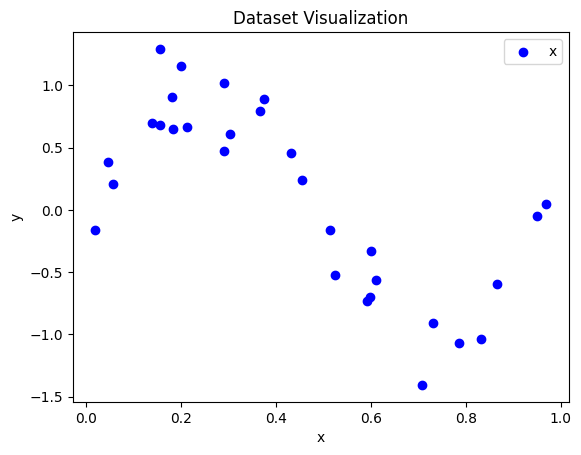

In [7]:

import matplotlib.pyplot as plt

plt.scatter(df["x"], df["y"], color="blue", label="x")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title("Dataset Visualization")
plt.show()

In [9]:
x_train,X_test,y_train,y_test=train_test_split(df["x"],df["y"],test_size=0.2,random_state=42)

In [10]:
lr=LinearRegression()

In [11]:
lr.fit(x_train.values.reshape(-1,1),y_train)

LinearRegression()

In [12]:
lr.predict(X_test.values.reshape(-1,1))

array([-0.60162028,  0.10816181, -0.34318859, -0.02634618,  0.4878259 ,
        0.4671235 ])

In [13]:
lr.coef_

array([-1.63457211])

In [14]:
lr.intercept_

np.float64(0.814207093125667)

In [15]:
r2_score(y_test,lr.predict(X_test.values.reshape(-1,1)) )

0.5953191976158698

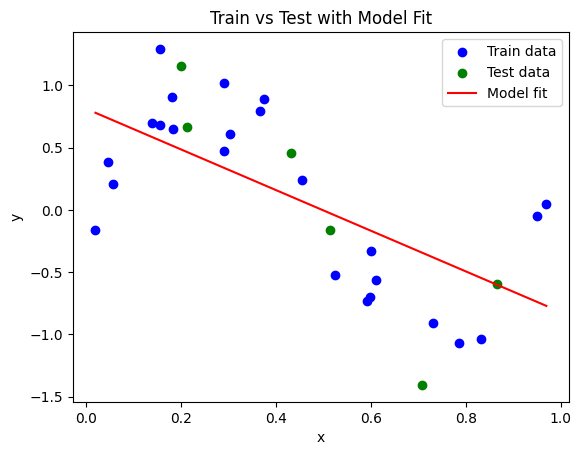

In [16]:
# visualization
import numpy as np
import matplotlib.pyplot as plt

plt.scatter(x_train, y_train, color="blue", label="Train data")
plt.scatter(X_test, y_test, color="green", label="Test data")

# regression line (sorted for smooth line)
x_range = np.linspace(df["x"].min(), df["x"].max(), 100).reshape(-1,1)
plt.plot(x_range, lr.predict(x_range), color="red", label="Model fit")

plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title("Train vs Test with Model Fit")
plt.show()

In [17]:
from sklearn.preprocessing import PolynomialFeatures

In [19]:
degree=15

In [20]:
poly=PolynomialFeatures(degree=degree)

In [29]:
poly.fit(x_train.values.reshape(-1,1))
x_poly_train=poly.transform(x_train.values.reshape(-1,1))
x_poly_test=poly.transform(X_test.values.reshape(-1,1))

In [23]:
lr_POLY=LinearRegression()

In [24]:
lr_POLY.fit(x_poly_train,y_train)

LinearRegression()

In [25]:
Y_PREDICTION=lr_POLY.predict(x_poly_test)

In [27]:
Y_PREDICTION

array([-3.39073885,  0.48718005, -0.52527428, -0.42372879,  0.70435903,
        0.61796639])

In [48]:
r2_score(y_test,Y_PREDICTION)

-1.044761249574759

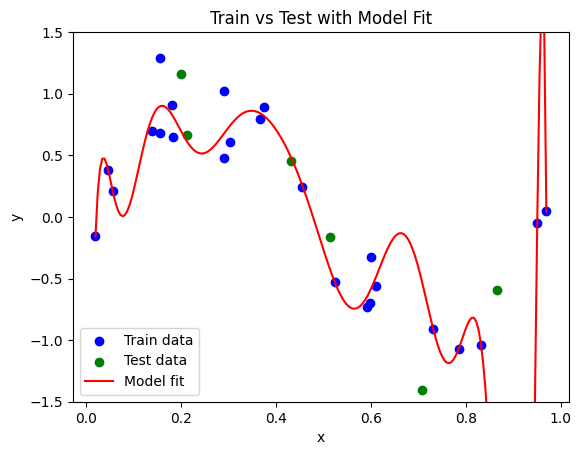

In [39]:
import numpy as np
import matplotlib.pyplot as plt

x_range = np.linspace(df["x"].min(), df["x"].max(), 200).reshape(-1,1)
x_range_poly = poly.transform(x_range)

plt.scatter(x_train, y_train, color="blue", label="Train data")
plt.scatter(X_test, y_test, color="green", label="Test data")
plt.plot(x_range, lr_POLY.predict(x_range_poly), color="red", label="Model fit")

plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title("Train vs Test with Model Fit")
plt.ylim(-1.5, 1.5)
plt.show()

In [40]:
r2_score(y_test, Y_PREDICTION)

-1.044761249574759

In [43]:
ridge=Ridge(alpha=0.01)

In [44]:
ridge.fit(x_poly_train,y_train)

Ridge(alpha=0.01)

In [46]:
r_predict=ridge.predict(x_poly_test)

In [47]:
r2_score(y_test,r_predict)

0.8517007882454324

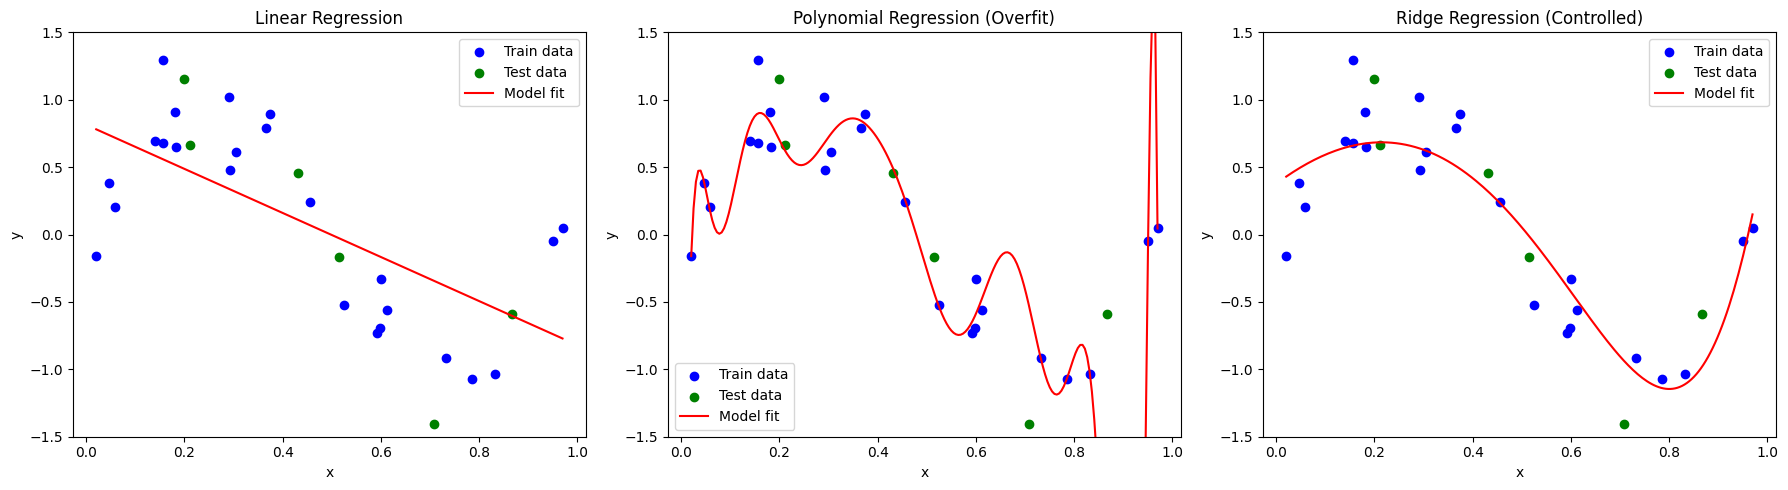

In [53]:
import numpy as np
import matplotlib.pyplot as plt

x_range = np.linspace(df["x"].min(), df["x"].max(), 200).reshape(-1,1)
x_range_poly = poly.transform(x_range)

fig, axes = plt.subplots(1, 3, figsize=(18,5))

# ---- Linear ----
axes[0].scatter(x_train, y_train, color="blue", label="Train data")
axes[0].scatter(X_test, y_test, color="green", label="Test data")
axes[0].plot(x_range, lr.predict(x_range), color="red", label="Model fit")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_title("Linear Regression")
axes[0].legend()
axes[0].set_ylim(-1.5, 1.5)


# ---- Polynomial ----
axes[1].scatter(x_train, y_train, color="blue", label="Train data")
axes[1].scatter(X_test, y_test, color="green", label="Test data")
axes[1].plot(x_range, lr_POLY.predict(x_range_poly), color="red", label="Model fit")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].set_title("Polynomial Regression (Overfit)")
axes[1].legend()
axes[1].set_ylim(-1.5, 1.5)

# ---- Ridge ----
axes[2].scatter(x_train, y_train, color="blue", label="Train data")
axes[2].scatter(X_test, y_test, color="green", label="Test data")
axes[2].plot(x_range, ridge.predict(x_range_poly), color="red", label="Model fit")
axes[2].set_xlabel("x")
axes[2].set_ylabel("y")
axes[2].set_title("Ridge Regression (Controlled)")
axes[2].legend()
axes[2].set_ylim(-1.5, 1.5)

plt.tight_layout()
plt.show()